In [1]:
import numpy as np
import matplotlib.pyplot as plt

from wilson_suite.wilson_intensities.amplitudes.domains import features_to_clusters
from wilson_suite.wilson_intensities.amplitudes.spectrum_composition import ResLocGeoObject, SpectralFeature

In [2]:
# ---- Example data ----
rng = np.random.default_rng(1)
res_locations = [tuple(p) for p in rng.uniform([0, 0], [10, 6], size=(15, 2))]
spec_feats = [SpectralFeature(location=ResLocGeoObject(dict(zip(['x', 'y'], i))), lineshape_parameter=0.4) for i in res_locations]
print(spec_feats[:2])

[SpectralFeature(location=Point(x=5.118216247002567, y=5.702782177955612), term_contributions=None, lineshape_parameter=0.4, amplitude_coeff=None, feat_type=None, feat_box=Box(bounds={'x': (np.float64(4.718216247002567), np.float64(5.5182162470025675)), 'y': (np.float64(5.302782177955612), np.float64(6.102782177955612))}, grid=None, has_grid=False)), SpectralFeature(location=Point(x=1.4415961271963373, y=5.691896682823463), term_contributions=None, lineshape_parameter=0.4, amplitude_coeff=None, feat_type=None, feat_box=Box(bounds={'x': (np.float64(1.0415961271963372), np.float64(1.8415961271963375)), 'y': (np.float64(5.291896682823463), np.float64(6.091896682823464))}, grid=None, has_grid=False))]


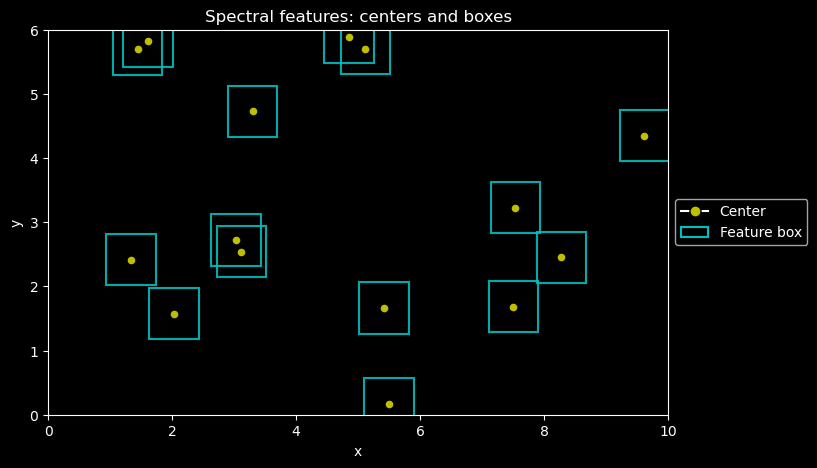

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
for sf in spec_feats:
    # center (support Point.x/Point.y or .values)
    if hasattr(sf.location, "x"):
        x, y = float(sf.location.x), float(sf.location.y)
    elif hasattr(sf.location, "values"):
        x, y = map(float, sf.location.values)
    else:
        x, y = map(float, sf.location)

    # feature box bounds
    fb = getattr(sf, "feat_box", None)
    if fb and getattr(fb, "bounds", None):
        xmin, xmax = map(float, fb.bounds["x"])
        ymin, ymax = map(float, fb.bounds["y"])
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             edgecolor="c", facecolor="none", linewidth=1.5, alpha=0.9)
        ax.add_patch(rect)

    ax.scatter(x, y, color="y", s=20, zorder=3)

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Spectral features: centers and boxes")
# ...existing code...
ax.set_title("Spectral features: centers and boxes")

# legend proxies for center and box
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='y', markeredgecolor='k', markersize=8, label='Center'),
    Patch(facecolor='none', edgecolor='c', linewidth=1.5, label='Feature box'),
]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [ ]:
sf_clustered = features_to_clusters(spec_feats)
clusters_for_plot = {k: [i.location.values for i in v] for k,v in sf_clustered.items()}
clusters_for_plot

{0: [(np.float64(5.118216247002567), np.float64(5.702782177955612)),
  (np.float64(4.851909744316351), np.float64(5.884423198807432))],
 1: [(np.float64(1.4415961271963373), np.float64(5.691896682823463)),
  (np.float64(1.6065200877512686), np.float64(5.819552479296796))],
 2: [(np.float64(3.1183145201048545), np.float64(2.539958693835454)),
  (np.float64(3.03194829291645), np.float64(2.7209873368839093))],
 3: [(np.float64(8.277025938204417), np.float64(2.4551948182149674)),
  (np.float64(7.503646726300525), np.float64(1.6824525479162395)),
  (np.float64(7.535131086748066), np.float64(3.228859879315669))],
 4: [(np.float64(5.495936876730595), np.float64(0.1653546794584102))],
 5: [(np.float64(3.297317164990922), np.float64(4.730572220570426))],
 6: [(np.float64(1.3404169724716475), np.float64(2.4186779186827754))],
 7: [(np.float64(2.034552406761496), np.float64(1.573880042651097))],
 8: [(np.float64(9.616571936637868), np.float64(4.348739644641202))],
 9: [(np.float64(5.4122685554743

smth else

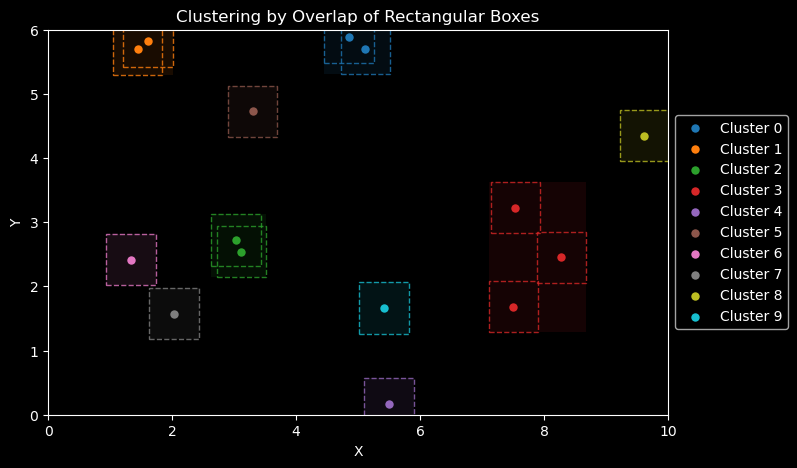

In [ ]:
# Example points
rng = np.random.default_rng(2)
points = [tuple(p) for p in rng.uniform([0, 0], [10, 6], size=(15, 2))]
box_halfwidths = {"x": 0.4, "y": 0.4}


# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters_for_plot)))

for (label, pts), color in zip(clusters_for_plot.items(), colors):
    pts = np.array(pts)
    ax.scatter(pts[:, 0], pts[:, 1], color=color, edgecolor='k', s=50, label=f"Cluster {label}")
    
    # Draw individual rectangles for each point (their influence area)
    for (x, y) in pts:
        rect = plt.Rectangle((x - box_halfwidths["x"], y - box_halfwidths["y"]),
                             2 * box_halfwidths["x"], 2 * box_halfwidths["y"],
                             fill=False, edgecolor=color, linestyle='--', linewidth=1, alpha=0.8)
        ax.add_patch(rect)
    
    # Draw cluster bounding box (union of all rectangles)
    xmin = min(x - box_halfwidths["x"] for x, y in pts)
    xmax = max(x + box_halfwidths["x"] for x, y in pts)
    ymin = min(y - box_halfwidths["y"] for x, y in pts)
    ymax = max(y + box_halfwidths["y"] for x, y in pts)
    ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               fill=True, alpha=0.1, facecolor=color, edgecolor='none'))

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Clustering by Overlap of Rectangular Boxes")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()
